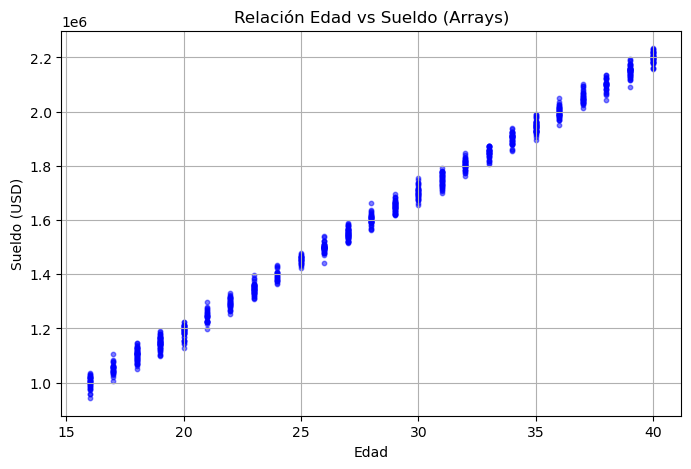

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple

def generate_arrays(
    n: int = 10000,
    relation: str = "increasing",
    noise_std: float = 20000.0,
    seed: Optional[int] = 42,
    age_min: int = 16,
    age_max: int = 40,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Genera dos arrays de NumPy: uno para edades (x) y otro para sueldos (y).
    """
    rng = np.random.default_rng(seed)
    
    # 1. Generar el array de edades (X)
    ages = rng.integers(age_min, age_max + 1, size=n)

    # 2. Configurar parámetros de la relación lineal
    if relation == "increasing":
        slope = 50000.0
        intercept = 200000.0
    else:
        slope = -50000.0
        intercept = 2000000.0

    # 3. Calcular sueldos con ruido (Y)
    noise = rng.normal(0.0, noise_std, size=n)
    salaries = intercept + (slope * ages) + noise
    
    # Limpiar: no permitir sueldos negativos
    salaries = np.clip(salaries, a_min=0.0, a_max=None)

    return ages, salaries

if __name__ == "__main__":
    # Obtenemos los dos arrays por separado
    edades, sueldos = generate_arrays(n=1000, relation="increasing")

    # Visualización rápida
    plt.figure(figsize=(8, 5))
    plt.scatter(edades, sueldos, alpha=0.5, s=10, color='blue')
    plt.title("Relación Edad vs Sueldo (Arrays)")
    plt.xlabel("Edad")
    plt.ylabel("Sueldo (USD)")
    plt.grid(True)
    plt.show()


In [10]:
print("Las edades")
print(edades)

Las edades
[18 35 32 26 26 37 18 33 21 18 29 40 34 35 33 35 28 19 36 27 28 25 20 39
 35 32 26 36 29 27 27 21 18 29 38 17 37 36 22 31 20 34 33 24 17 40 27 38
 32 35 34 20 25 27 28 17 29 19 34 33 39 34 25 40 26 24 38 25 17 27 35 20
 27 19 33 27 24 21 30 32 39 26 20 36 31 33 18 23 35 36 26 36 37 25 38 23
 21 33 31 19 36 20 36 16 35 35 35 32 27 33 22 35 29 27 28 30 16 19 22 18
 26 32 32 27 37 30 17 35 30 31 30 29 18 29 35 23 31 16 24 26 40 21 22 26
 40 37 16 21 36 17 37 23 38 23 26 32 19 29 28 35 40 32 26 26 26 36 24 20
 24 16 18 18 35 34 33 27 33 20 38 28 39 19 28 33 28 27 20 25 21 23 33 31
 31 25 39 18 24 18 24 40 25 38 28 33 27 22 35 40 22 35 22 33 35 27 34 22
 17 18 27 38 19 27 33 21 34 23 36 30 29 20 27 37 16 34 28 33 32 26 23 31
 19 30 18 32 31 18 34 26 35 17 20 28 20 24 32 19 32 18 20 30 35 20 23 39
 40 30 27 24 31 30 23 16 19 39 26 28 27 35 17 18 22 28 32 28 27 39 20 30
 29 27 36 22 39 24 29 29 37 26 23 16 25 36 16 38 29 19 23 29 23 18 32 32
 18 23 22 32 34 34 39 35 24 18 31 38 40 

In [11]:
print("Los sueldos")
print(sueldos)

Los sueldos
[1128664.29013212 1951830.40356346 1811615.5419066  1498864.33611215
 1496591.84837672 2034410.35206549 1108606.02717915 1832969.25621628
 1263311.70472627 1121705.74008892 1657330.62814474 2194275.02532889
 1909079.31158617 1943826.53888907 1868710.9425093  1913371.8783157
 1593287.85263763 1110183.76009752 1970098.78339546 1577277.24459628
 1617903.69963943 1435610.3953343  1169949.93087918 2090709.42324317
 1939130.08984135 1848408.30024495 1508697.68542927 1988808.55427901
 1659301.60419001 1518780.83294011 1544053.53274605 1251989.54946031
 1098277.98696358 1665816.1224338  2106892.90452472 1063366.52036216
 2036232.55435538 2017956.30816821 1332578.73895248 1730597.00960697
 1182246.08688571 1926715.6867264  1846173.1202661  1428076.42784133
 1041149.28576216 2229100.91152541 1552629.71633611 2105164.57646645
 1831294.3604334  1942764.59045112 1881177.5580815  1191028.71583943
 1459046.67901286 1518684.81855639 1612749.41805302 1039224.57364765
 1672956.25321467 11021

In [16]:
m_deseado = 0 #theta1 o b
b_deseado = 0 #theta0 o a

# Rangos para los coeficientes
rango_a = np.arange(40000, 60000, 20)  # Rango para el término independiente (a)
rango_b = np.arange(150000, 250000, 20)  # Rango para el coeficiente de x (b)

print(rango_a)
print("#")
print(rango_b)

[40000 40020 40040 40060 40080 40100 40120 40140 40160 40180 40200 40220
 40240 40260 40280 40300 40320 40340 40360 40380 40400 40420 40440 40460
 40480 40500 40520 40540 40560 40580 40600 40620 40640 40660 40680 40700
 40720 40740 40760 40780 40800 40820 40840 40860 40880 40900 40920 40940
 40960 40980 41000 41020 41040 41060 41080 41100 41120 41140 41160 41180
 41200 41220 41240 41260 41280 41300 41320 41340 41360 41380 41400 41420
 41440 41460 41480 41500 41520 41540 41560 41580 41600 41620 41640 41660
 41680 41700 41720 41740 41760 41780 41800 41820 41840 41860 41880 41900
 41920 41940 41960 41980 42000 42020 42040 42060 42080 42100 42120 42140
 42160 42180 42200 42220 42240 42260 42280 42300 42320 42340 42360 42380
 42400 42420 42440 42460 42480 42500 42520 42540 42560 42580 42600 42620
 42640 42660 42680 42700 42720 42740 42760 42780 42800 42820 42840 42860
 42880 42900 42920 42940 42960 42980 43000 43020 43040 43060 43080 43100
 43120 43140 43160 43180 43200 43220 43240 43260 43

In [17]:
mejor_error = float('inf')
mejor_a = None
mejor_b = None

# Bucle para probar diferentes combinaciones de coeficientes
for b in rango_b:
    for a in rango_a:
        error_acumulado = 0
        for indice, x in enumerate(edades):

          # Calcular valores de y predichos por la ecuación
          y_pred = a * x + b

          # error_actual = y_pred - precios[indice]
          error_actual = (y_pred - sueldos[indice])**2
          # print(x, precios[indice])

          error_acumulado = error_acumulado + error_actual

        # Actualizar los mejores coeficientes si encontramos un mejor ajuste
        error_acumulado = error_acumulado * (1 /(2 * len(edades)))
        if error_acumulado < mejor_error:
            mejor_error = error_acumulado
            mejor_a = a
            mejor_b = b

print("Coeficiente de x (m) más cercano:", mejor_a)
print("Término independiente (b) más cercano:", mejor_b)

KeyboardInterrupt: 

In [13]:
y_pred = mejor_a * 32 + mejor_b
print("Valor de y predicho para x=32:", y_pred)

Valor de y predicho para x=32: 325000
